In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

In [2]:
pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 1000)
sns.set(style="darkgrid")

In [9]:
movies_df = pd.read_csv(r"C:\Users\fadwa\Downloads\ml-32m\ml-32m\movies.csv")
ratings_df = pd.read_csv(r"C:\Users\fadwa\Downloads\ml-32m\ml-32m\ratings.csv")
tags_df = pd.read_csv(r"C:\Users\fadwa\Downloads\ml-32m\ml-32m\tags.csv")
links_df = pd.read_csv(r"C:\Users\fadwa\Downloads\ml-32m\ml-32m\links.csv")

In [10]:
 movies_df.head()

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [11]:
ratings_df.head()

,userId,movieId,rating,timestamp
0,1,17,4.0,944249077
1,1,25,1.0,944250228
2,1,29,2.0,943230976
3,1,30,5.0,944249077
4,1,32,5.0,943228858


In [12]:
tags_df.head()

,userId,movieId,tag,timestamp
0,22,26479,Kevin Kline,1583038886
1,22,79592,misogyny,1581476297
2,22,247150,acrophobia,1622483469
3,34,2174,music,1249808064
4,34,2174,weird,1249808102


In [13]:
links_df.head()

,movieId,imdbId,tmdbId
0,1,114709,862.0
1,2,113497,8844.0
2,3,113228,15602.0
3,4,114885,31357.0
4,5,113041,11862.0


In [15]:
# Cleaning & Filtering
ratings_df.dropna(inplace=True)

user_counts = ratings_df['userId'].value_counts()
movie_counts = ratings_df['movieId'].value_counts()

ratings_df = ratings_df[ratings_df['userId'].isin(user_counts[user_counts >= 20].index)]
ratings_df = ratings_df[ratings_df['movieId'].isin(movie_counts[movie_counts >= 20].index)]

ratings_merged = ratings_df.merge(movies_df, on='movieId', how='left')


In [17]:
# Show the first few rows of the cleaned ratings DataFrame
print("Cleaned Ratings:\n", ratings_df.head())

# Check the new shape (rows, columns)
print("\nShape of cleaned ratings:", ratings_df.shape)

# Optional: Check how many unique users and movies remain
print("\nUnique users:", ratings_df['userId'].nunique())
print("Unique movies:", ratings_df['movieId'].nunique())


Cleaned Ratings:
    userId  movieId  rating  timestamp
0       1       17     4.0  944249077
1       1       25     1.0  944250228
2       1       29     2.0  943230976
3       1       30     5.0  944249077
4       1       32     5.0  943228858

Shape of cleaned ratings: (31722609, 4)

Unique users: 200763
Unique movies: 23350


In [18]:
#Rating Normalization
user_avg = ratings_df.groupby('userId')['rating'].mean()
ratings_df = ratings_df.join(user_avg, on='userId', rsuffix='_avg')
ratings_df['rating_centered'] = ratings_df['rating'] - ratings_df['rating_avg']

In [19]:
# Show selected columns to verify normalization
ratings_df[['userId', 'movieId', 'rating', 'rating_avg', 'rating_centered']].head()

,userId,movieId,rating,rating_avg,rating_centered
0,1,17,4.0,3.531915,0.468085
1,1,25,1.0,3.531915,-2.531915
2,1,29,2.0,3.531915,-1.531915
3,1,30,5.0,3.531915,1.468085
4,1,32,5.0,3.531915,1.468085


In [20]:
#Train/Test Split
train_df, test_df = train_test_split(ratings_df, test_size=0.2, random_state=42)

train_df[['userId', 'movieId', 'rating']].to_csv('als_train.csv', index=False)
test_df[['userId', 'movieId', 'rating']].to_csv('als_test.csv', index=False)


In [22]:
# Load back the saved files (optional but useful for confirmation)
train_df_check = pd.read_csv("als_train.csv")
test_df_check = pd.read_csv("als_test.csv")

# Show shape of splits
print("Training set shape:", train_df_check.shape)
print("Test set shape:", test_df_check.shape)

# Preview top 5 rows of each
print("\nTraining Set Sample:\n", train_df_check.head())
print("\nTest Set Sample:\n", test_df_check.head())


Training set shape: (25378087, 3)
Test set shape: (6344522, 3)

Training Set Sample:
    userId  movieId  rating
0    7855     1689     4.5
1   75962     1136     4.0
2   80396      380     5.0
3  142835     1240     4.0
4  182742    81834     4.5

Test Set Sample:
    userId  movieId  rating
0   24708       32     5.0
1   55567       32     3.0
2   26659    34048     4.0
3  123111     1198     4.5
4   40751    64983     3.5


In [23]:
#Save Encoded Data for Spark ALS
train_df['userId'] = train_df['userId'].astype(int)
train_df['movieId'] = train_df['movieId'].astype(int)
train_df[['userId', 'movieId', 'rating']].to_csv('als_input.csv', index=False)


In [24]:
# Load the CSV back for confirmation
als_input_df = pd.read_csv("als_input.csv")

# Show shape and first few rows
print("ALS Input Shape:", als_input_df.shape)
print("\nSample from ALS Input:")
print(als_input_df.head())


ALS Input Shape: (25378087, 3)

Sample from ALS Input:
   userId  movieId  rating
0    7855     1689     4.5
1   75962     1136     4.0
2   80396      380     5.0
3  142835     1240     4.0
4  182742    81834     4.5


In [25]:
!pip install implicit

  Obtaining dependency information for implicit from https://files.pythonhosted.org/packages/7c/25/48964efed207b60b2d5b2855161638e4f368f5db332b57f62b6cd16fb591/implicit-0.7.2-cp311-cp311-win_amd64.whl.metadata
   ---------------------------------------- 0.0/750.8 kB ? eta -:--:--
    --------------------------------------- 10.2/750.8 kB ? eta -:--:--
   - ------------------------------------- 30.7/750.8 kB 435.7 kB/s eta 0:00:02
   -- ------------------------------------ 41.0/750.8 kB 388.9 kB/s eta 0:00:02
   ------- ------------------------------ 143.4/750.8 kB 944.1 kB/s eta 0:00:01
   ------------ --------------------------- 225.3/750.8 kB 1.3 MB/s eta 0:00:01
   -------------------- ------------------- 389.1/750.8 kB 1.7 MB/s eta 0:00:01
   ----------------------- ---------------- 440.3/750.8 kB 1.8 MB/s eta 0:00:01
   ----------------------- ---------------- 440.3/750.8 kB 1.8 MB/s eta 0:00:01
   ---------------------------------------  747.5/750.8 kB 2.4 MB/s eta 0:00:01
   ----

In [29]:
from scipy.sparse import coo_matrix

# Create COO matrix, then convert to CSR
user_ids = ratings_df['userId'].astype("category").cat.codes
item_ids = ratings_df['movieId'].astype("category").cat.codes

coo = coo_matrix((ratings_df['rating'], (item_ids, user_ids)))
sparse_matrix = coo.tocsr()  # convert to CSR here


In [30]:
from implicit.als import AlternatingLeastSquares

# Initialize ALS model
model = AlternatingLeastSquares(
    factors=50,
    regularization=0.1,
    iterations=20,
    use_gpu=False
)

# Fit model (implicit library needs item-user matrix)
model.fit(sparse_matrix)


  0%|          | 0/20 [00:00<?, ?it/s]

In [50]:
def recommend_top_movies_for_user(target_user_id, top_n=5):
    if target_user_id not in reverse_user_mapping:
        print(f"User ID {target_user_id} not found in training data.")
        return

    user_code = reverse_user_mapping[target_user_id]
    user_vector = sparse_matrix.T.tocsr()[user_code]

    try:
        # Ask for more results than needed in case some are filtered
        recommendations = model.recommend(
            user_code,
            user_vector,
            N=top_n * 5,  # request more to get at least top_n
            filter_already_liked_items=True
        )

        # Extract and map back to original movieIds
        recommended_movie_ids = [item_mapping[int(rec[0])] for rec in recommendations][:top_n]

        # Fetch titles
        recommended_titles = movies_df[movies_df['movieId'].isin(recommended_movie_ids)][['movieId', 'title']]
        
        print(f"\nTop {len(recommended_titles)} recommended movies for user {target_user_id}:\n")
        print(recommended_titles.to_string(index=False))

    except Exception as e:
        print(f"Error during recommendation: {e}")


In [54]:
# Recommend top 5 movies for user 1
recommend_top_movies_for_user(target_user_id=34, top_n=10)



Top 2 recommended movies for user 34:

 movieId                    title
       2           Jumanji (1995)
  201270 Remi Nobody's Boy (2018)


In [61]:
# Map userId/movieId to ALS internal codes (drop missing ones)
test_df['user_code'] = test_df['userId'].map(reverse_user_mapping)
test_df['item_code'] = test_df['movieId'].map(reverse_item_mapping)

# Drop unmapped users/items
test_df_clean = test_df.dropna(subset=['user_code', 'item_code']).copy()
test_df_clean['user_code'] = test_df_clean['user_code'].astype(int)
test_df_clean['item_code'] = test_df_clean['item_code'].astype(int)

# Keep only rows with valid indices within ALS factor arrays
test_df_clean = test_df_clean[
    (test_df_clean['user_code'] < model.user_factors.shape[0]) &
    (test_df_clean['item_code'] < model.item_factors.shape[0])
]


In [62]:
# Predict ratings using dot product
predictions = [
    np.dot(
        model.user_factors[int(row['user_code'])],
        model.item_factors[int(row['item_code'])]
    )
    for _, row in test_df_clean.iterrows()
]

test_df_clean['prediction'] = predictions

# Compute RMSE
rmse = np.sqrt(mean_squared_error(test_df_clean['rating'], test_df_clean['prediction']))
print(f"ALS Model RMSE on Test Set: {rmse:.4f}")


ALS Model RMSE on Test Set: 3.6869


In [63]:
def precision_at_k(df, k=10):
    precisions = []

    for user_id in df['userId'].unique():
        user_data = df[df['userId'] == user_id]
        top_k = user_data.sort_values('prediction', ascending=False).head(k)
        relevant = top_k[top_k['rating'] >= 4.0]
        precisions.append(len(relevant) / k)

    return np.mean(precisions)

# Run precision@10 on your cleaned prediction set
p_at_k = precision_at_k(test_df_clean, k=10)
print(f"Precision@10: {p_at_k:.4f}")

Precision@10: 0.4920


In [64]:
def recommend_by_genre(genre, n=10):
    # Filter movies by genre string
    genre_movies = movies_df[movies_df['genres'].str.contains(genre, case=False, na=False)]

    # Filter ratings to only those movies
    genre_ratings = ratings_df[ratings_df['movieId'].isin(genre_movies['movieId'])]

    # Group and sort by average rating and count
    top = (
        genre_ratings.groupby('movieId')
        .agg(avg_rating=('rating', 'mean'), count=('rating', 'count'))
        .sort_values(['avg_rating', 'count'], ascending=False)
        .head(n)
    )

    return movies_df[movies_df['movieId'].isin(top.index)][['movieId', 'title', 'genres']]


In [66]:
recommend_by_genre("Sci-Fi", n=5)


,movieId,title,genres
2480,2571,"Matrix, The (1999)",Action|Sci-Fi|Thriller
14939,79132,Inception (2010),Action|Crime|Drama|Mystery|Sci-Fi|Thriller|IMAX
57705,195159,Spider-Man: Into the Spider-Verse (2018),Action|Adventure|Animation|Sci-Fi
70818,228099,Firefly (2002),Action|Adventure|Sci-Fi|Western
85883,286897,Spider-Man: Across the Spider-Verse (2023),Action|Adventure|Animation|Sci-Fi


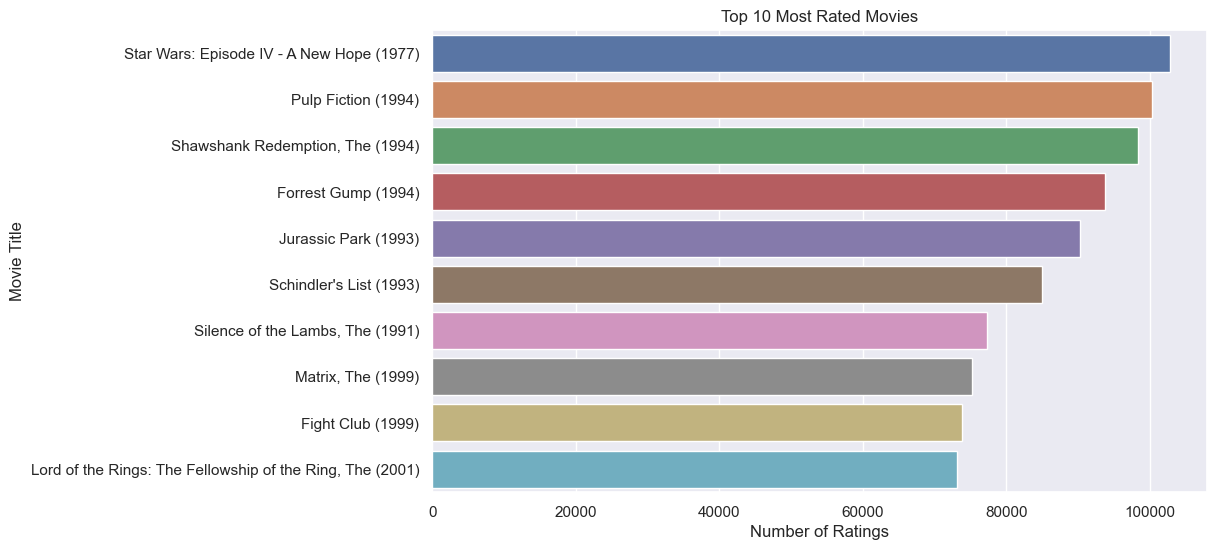

In [68]:
top_rated = ratings_df['movieId'].value_counts().head(10)
top_movies = movies_df[movies_df['movieId'].isin(top_rated.index)]

plt.figure(figsize=(10, 6))
sns.barplot(y=top_movies['title'], x=top_rated.values)
plt.title("Top 10 Most Rated Movies")
plt.xlabel("Number of Ratings")
plt.ylabel("Movie Title")
plt.show()


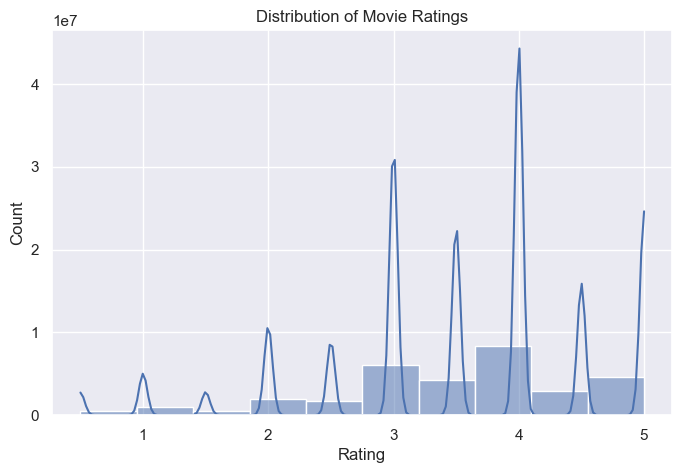

In [70]:
plt.figure(figsize=(8, 5))
sns.histplot(ratings_df['rating'], bins=10, kde=True)
plt.title("Distribution of Movie Ratings")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()
